# Delivery Time Prediction System


### Business Probelm

#### Food delivery companies need to predict delivery times accurately.

###### Why?

######      1.Improve customer satisfaction
######      2.Provide accurate delivery estimates
######      3.Optimize delivery operations
######      4.Reduce delays and complaints
######      5.Improve resource allocation

## Dataset Description

| Column Name | Meaning | Type | Unit / Example | Importance |
|------------|---------|------|----------------|------------|
| `Order_ID` | Unique identifier for each order | Categorical | `ORD1001` | Used for record identification, not useful for prediction |
| `Distance_km` | Distance between restaurant and customer | Numerical | `8.5 km` | Major factor affecting delivery time |
| `Weather` | Weather condition during delivery | Categorical | `Rainy`, `Sunny` | Impacts travel speed and delivery duration |
| `Traffic_Level` | Traffic condition on delivery route | Categorical | `Low`, `Medium`, `High` | Strongly influences delivery time |
| `Time_of_Day` | Time period when the order was placed | Categorical | `Morning`, `Evening` | Traffic and order volume vary by time |
| `Vehicle_Type` | Vehicle used by delivery partner | Categorical | `Bike`, `Scooter`, `Car` | Different vehicles have different delivery speeds |
| `Preparation_Time_min` | Time taken by restaurant to prepare the order | Numerical | `20 min` | Directly contributes to total delivery time |
| `Courier_Experience_yrs` | Delivery partner experience | Numerical | `5 years` | Experienced couriers may complete deliveries faster |
| `Delivery_Time_min` | Actual delivery duration | Target Variable | `45 min` | Variable to be predicted by the model |

### Dataset Summary

- **Dataset Name:** Food Delivery Time Prediction Dataset
- **Target Variable:** `Delivery_Time_min`
- **Number of Features:** 8
- **Number of Target Variables:** 1
- **Problem Type:** Regression
- **Machine Learning Algorithm Used:** Gradient Boosting Regressor

## PHASE 1- Delivery Data Understanding and Analysis

### Step 1 - Import libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Step 2 - Load Dataset

In [6]:
df=pd.read_csv("Downloads/Delivery_Time_Dataset.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'Downloads/Delivery_Time_Dataset.csv'

### Step 3 - View First Rows

In [ ]:
df.head()

### Step 4 - Dataset Shape

In [4]:
df.shape

(1000, 9)

### Step 5 - Column Names

In [5]:
df.columns

Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='str')

### Step 6 - Stastical Summary

In [6]:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


### Step 7 - Missing values

In [7]:
df.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

### Step 8 - Handle Missing Values

In [8]:
df.dropna(inplace=True)

In [9]:
df.isnull().sum()

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64

### Step 9 - Delivery Time Distribution

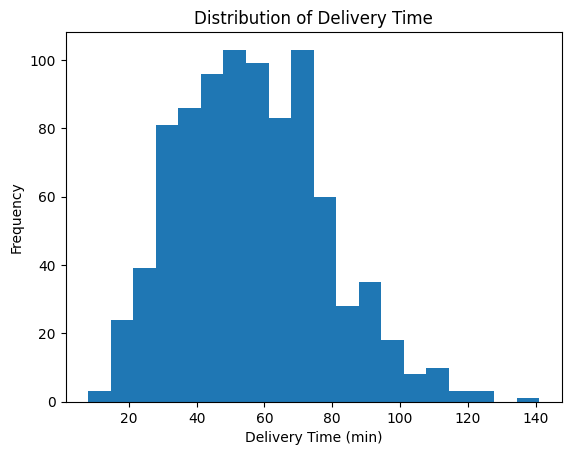

In [10]:

plt.hist(df['Delivery_Time_min'], bins=20)
plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (min)")
plt.ylabel("Frequency")
plt.show()

### Step 10 - Delivery Time Boxplot

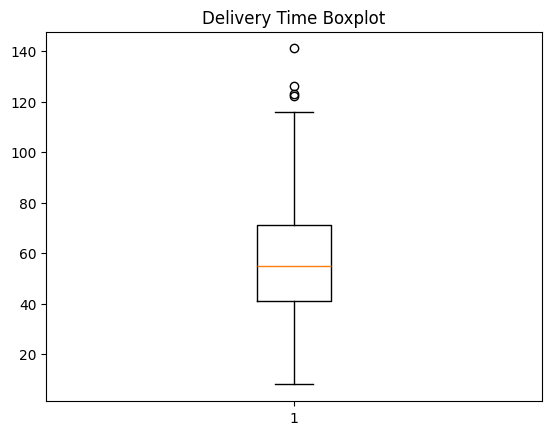

In [11]:
plt.boxplot(df['Delivery_Time_min'])
plt.title("Delivery Time Boxplot")
plt.show()

### Step 11 - Distance Vs Delivery TIme

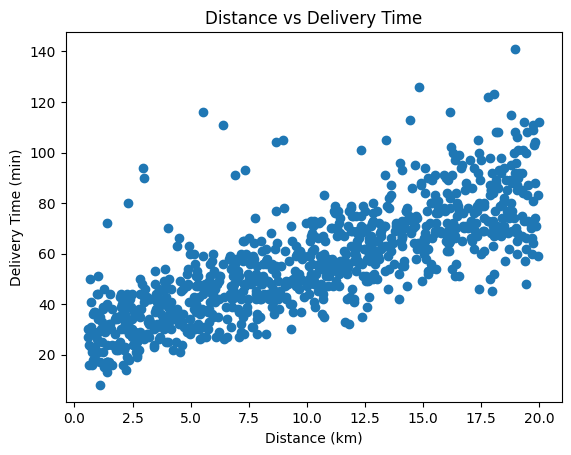

In [12]:
plt.scatter(df['Distance_km'], df['Delivery_Time_min'])
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (min)")
plt.title("Distance vs Delivery Time")
plt.show()

### Step 12 - Traffic Level Distribution

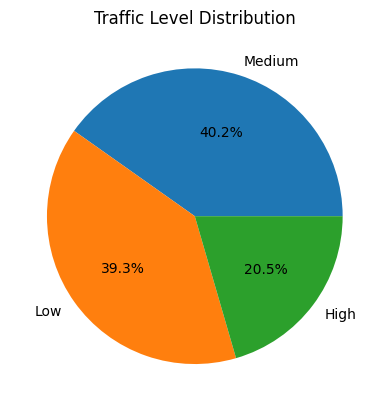

In [13]:
df['Traffic_Level'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title("Traffic Level Distribution")
plt.ylabel("")
plt.show()

### Step 13 - Weather Vs Delivery Time

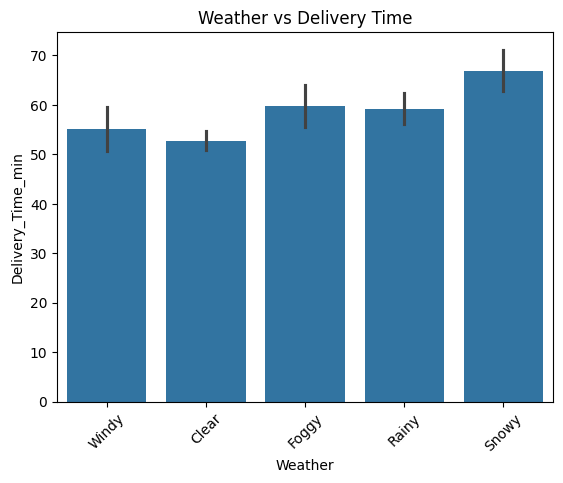

In [14]:
import seaborn as sns

sns.barplot(
    x='Weather',
    y='Delivery_Time_min',
    data=df
)
plt.title("Weather vs Delivery Time")
plt.xticks(rotation=45)
plt.show()

### Step 14 - Correlation Heatmap

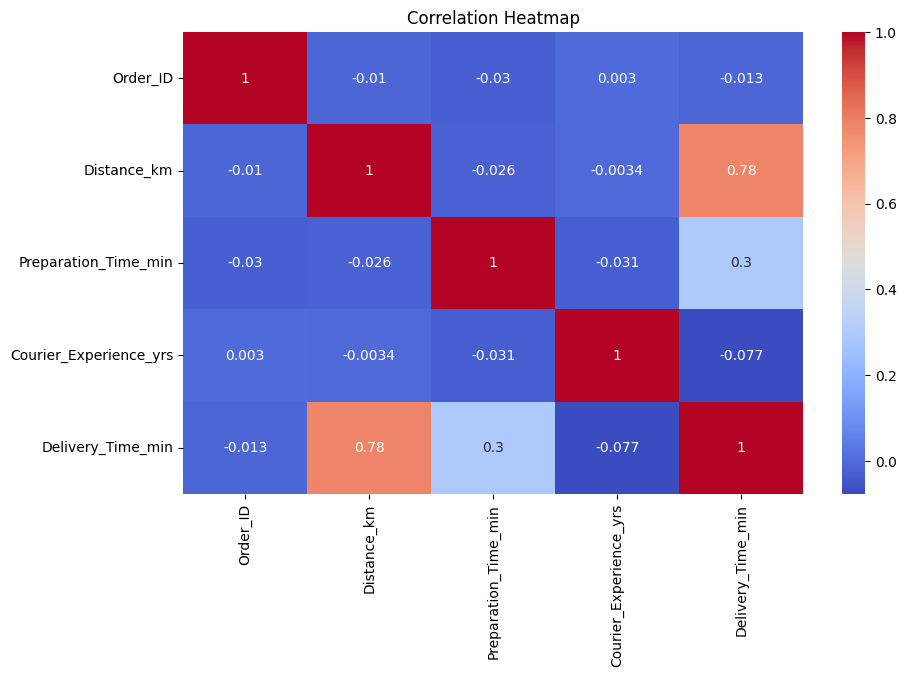

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include=['int64', 'float64']).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

## PHASE 2 = Data Preprocessing and Feature Engineering

### Step 1 - Check missing values

In [16]:
df.isnull().sum()

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64

### Step 2 - Drop Unnecessary Column

In [17]:
df.drop('Order_ID', axis=1, inplace=True)

### Step 3 - Encode Categorical Feature

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = [
    'Weather',
    'Traffic_Level',
    'Time_of_Day',
    'Vehicle_Type'
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

### Step 4 - Correlation Heatmap After Preprocessing

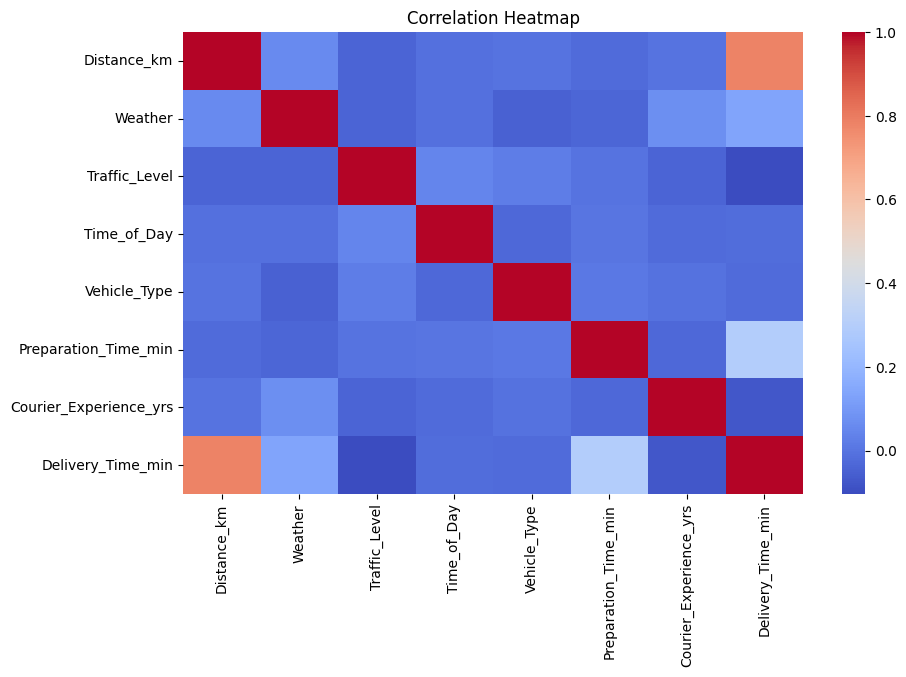

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(),
    cmap='coolwarm',
    annot=False
)

plt.title("Correlation Heatmap")
plt.show()

### Step 5 - Define Features and Target

In [20]:
X = df.drop('Delivery_Time_min', axis=1)

y = df['Delivery_Time_min']

### Step 6 - Train-Test Split

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## PHASE 3 - Delivery Time Predeiction Model

### ✅ Gradient Boosting Regressor

#### Why Gradient Boosting?
####      1.Handles non-linear relationships
####      2.High predictive accuracy
####      3.Works well on tabular data
####      4.Reduces prediction errors iteratively
####      5.Handles complex delivery patterns

#### Step 1 - Import Algorithm

In [22]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

#### Step 2 - Create Model

In [23]:
gbr = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

#### Step 3 - Train Model

In [24]:
gbr.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

#### Step 4 - Predict Test Data

In [25]:
y_pred = gbr.predict(X_test)

#### Step 5 - Calculate Metrics and Print Results

In [26]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R² Score :", r2)

MAE : 6.570725307371328
MSE : 90.27081588111471
RMSE : 9.501095509524927
R² Score : 0.7791378455022827


#### Step 6 - Actual Vs Predicted Vsualizaton

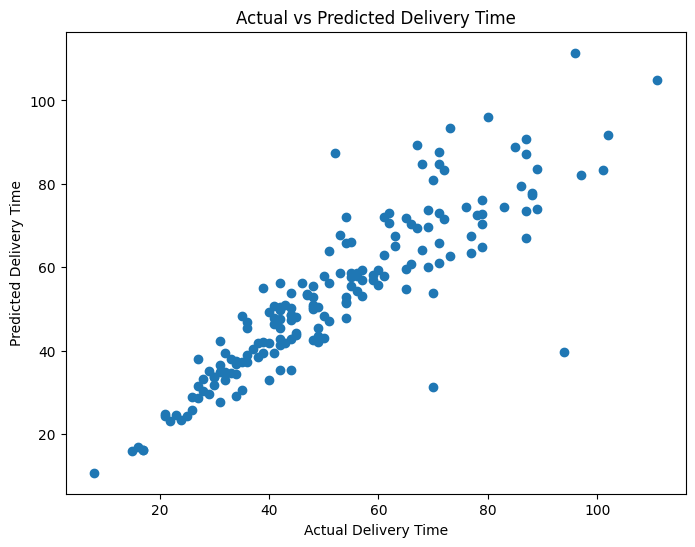

In [27]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted Delivery Time")

plt.show()

#### Step 7 - Feature Importance Analysis

In [28]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gbr.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                  Feature  Importance
0             Distance_km    0.761126
5    Preparation_Time_min    0.142328
2           Traffic_Level    0.046771
1                 Weather    0.028438
6  Courier_Experience_yrs    0.017164
4            Vehicle_Type    0.002446
3             Time_of_Day    0.001726


#### Step 8 Visualize Feature Importance

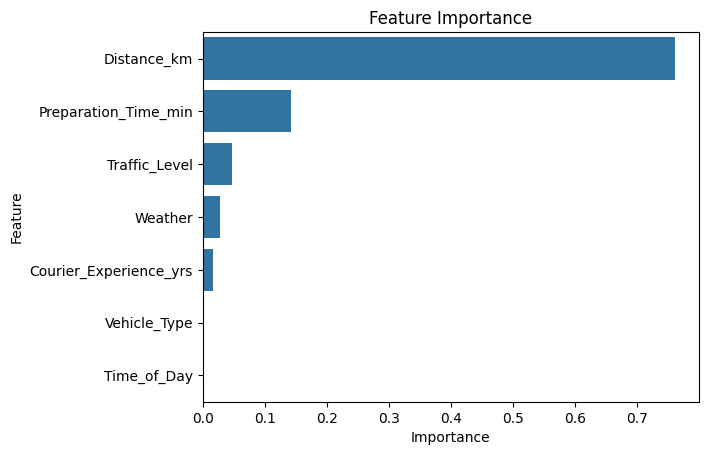

In [29]:
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance")
plt.show()

## PHASE 4 - Delivery Time Prediction System

#### Step 1 - Create New Delivery Input

In [30]:
new_data = pd.DataFrame({
    'Distance_km':[12],
    'Weather':[1],
    'Traffic_Level':[2],
    'Time_of_Day':[3],
    'Vehicle_Type':[0],
    'Preparation_Time_min':[20],
    'Courier_Experience_yrs':[5]
})

#### Step 2 - Match Training Columns

In [31]:
new_data = new_data[X.columns]

#### Step 3 - Predict Delivery TIme

In [32]:
predicted_time = gbr.predict(new_data)

#### Step 4 - Display Prediction

In [33]:
print("Predicted Delivery Time:", predicted_time[0], "minutes")

Predicted Delivery Time: 68.16924400955145 minutes


## Delivery Time Prediction System

Including:

✅ Data preprocessing and cleaning

✅ Missing value handling

✅ Feature encoding

✅ Exploratory Data Analysis (EDA)

✅ Correlation analysis

✅ Gradient Boosting Regressor model

✅ Delivery time prediction system

✅ Feature importance analysis

✅ Actual vs Predicted performance evaluation

✅ Reusable delivery time prediction function

✅ Real-world logistics prediction workflow